In [ ]:
# Importera bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("TensorFlow version:", tf.__version__)

tf.keras.utils.set_random_seed(42)

TensorFlow version: 2.21.0


In [17]:
# Plot history funktion

def plot_history(history, figsize=(12,4)):

    """
    Plot models history comparing loss and val_loss and comparing accuracy and val_accuracy.

    history: Models history.

    figsize: adjustable figure size. 
    """

    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)

    plt.plot(epochs, history_df["loss"], label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation Loss")
    
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()


    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)

    plt.plot(epochs, history_df["accuracy"], label="Training Loss")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation Loss")
    
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()



In [2]:
# Ladda in Fashion MNIST

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()


print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Antal klasser:", len(np.unique(y_train_full)))
print("Klasser:", np.unique(y_train_full))

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Antal klasser: 10
Klasser: [0 1 2 3 4 5 6 7 8 9]


In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [4]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distrubtion = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name":[class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distrubtion

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


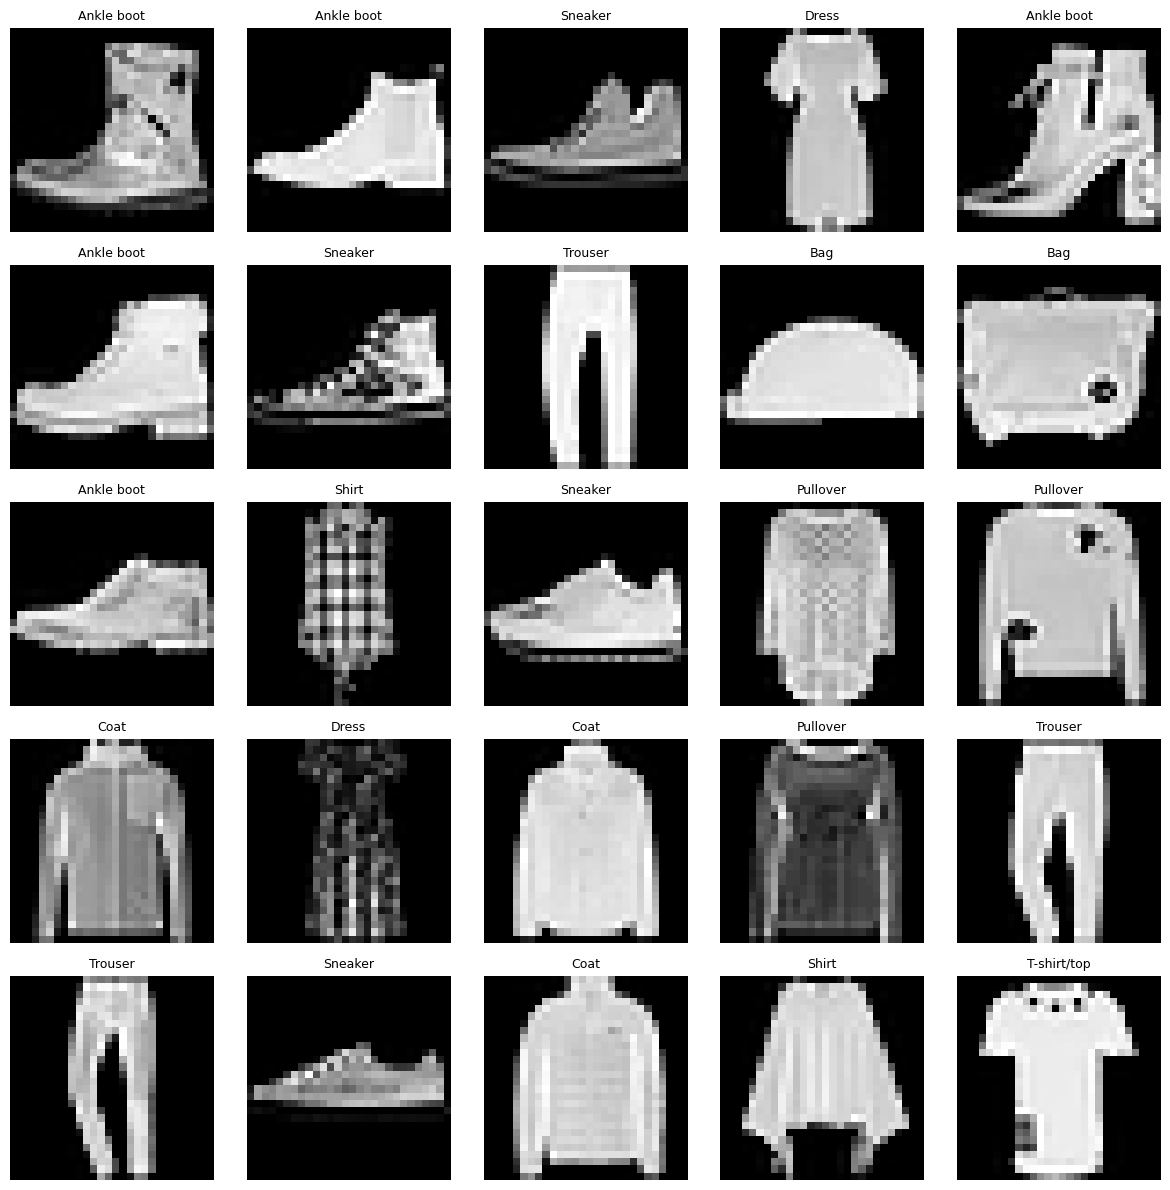

In [5]:
def plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices=rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index], cmap="gray")
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_image_grid(
        X_train_full,
        y_train_full,
        class_names,
        n_images=25
    )


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [7]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") /255.0
X_test = X_test.astype("float32") /255.0

print("Minsta värdet efter normalisering", X_train.min())
print("Största värdet efter normalisering", X_train.max())




Minsta värdet efter normalisering 0.0
Största värdet efter normalisering 1.0


In [8]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


In [ ]:
print("Exempel på labels:", y_train[:10])

Exempel på labels: [8 9 8 0 1 9 4 6 6 8]


In [22]:
# Clear session to make a fresh session.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

In [23]:


baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
## Marcus 

dropout02_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(10, activation="softmax")
])

dropout02_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)


dropout02_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
dropout02_history = dropout02_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs = 30,
    batch_size = 64
)


Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8024 - loss: 0.5454 - val_accuracy: 0.8788 - val_loss: 0.3347
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8686 - loss: 0.3619 - val_accuracy: 0.8993 - val_loss: 0.2792
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8846 - loss: 0.3183 - val_accuracy: 0.9078 - val_loss: 0.2521
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8943 - loss: 0.2900 - val_accuracy: 0.9137 - val_loss: 0.2330
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9008 - loss: 0.2690 - val_accuracy: 0.9138 - val_loss: 0.2231
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9074 - loss: 0.2507 - val_accuracy: 0.9127 - val_loss: 0.2331
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9142 - loss: 0.2356 - val_accuracy: 0.9200 - val_loss: 0.2183
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9148 - loss: 0.2287 - 

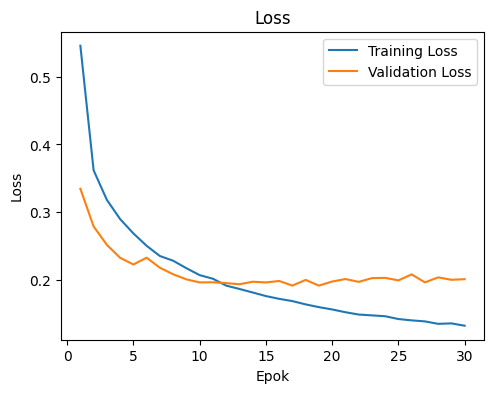

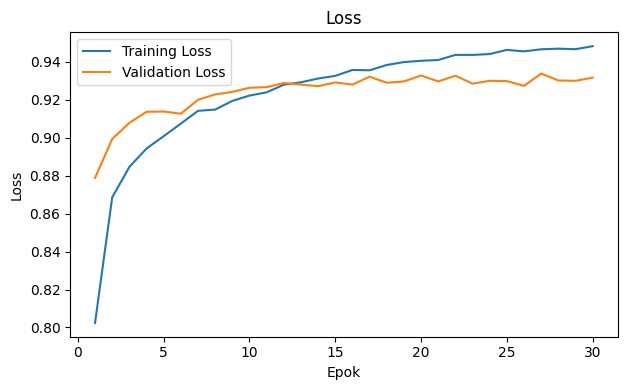

In [26]:
plot_history(dropout02_history)

In [27]:
dropout02_model.save("dropout02_cnn_model.keras")

In [ ]:
loaded_dropout02_model = keras.models.load_model("dropout02_cnn_model.keras")